# End-to-end ML Project: Bank Marketing Term Deposit Prediction

## Table of Contents
1. [Get the Data](#get-the-data)
2. [Exploratory Data Analysis](#exploratory-data-analysis)
    * [Missing Data Analysis](#missing-data-analysis)
    * [Looking for Correlations](#looking-for-correlations)
    * [Multicollinearity Analysis](#multicollinearity-analysis)
3. [Data Preprocessing](#data-preprocessing)
    * [Handling Missing Values](#handling-missing-values)
    * [Feature Transformations](#feature-transformations)
    * [Categorical Encoding](#categorical-encoding)
    * [Feature Scaling](#feature-scaling)
    * [Transformation Pipeline](#transformation-pipeline)
4. [Model Selection and Training](#model-selection-and-training)
    * [Baseline Models](#baseline-models)
    * [Cross-Validation](#cross-validation)
    * [Hyperparameter Tuning](#hyperparameter-tuning)
5. [Model Evaluation](#model-evaluation)

## Import Libraries

In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb

from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor

optuna.logging.set_verbosity(optuna.logging.WARNING)


C:\Users\youpi\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Get the Data

In [3]:
# Load the dataset
bank_x_train = pd.read_csv("bank_X_train.csv")
bank_y_train = pd.read_csv("bank_y_train.csv")
bank_x_test = pd.read_csv("bank_X_test.csv")

# Combine for exploratory analysis (without labels)
bank_total_no_labels = pd.concat([bank_x_train, bank_x_test], ignore_index=True)

# Combine features with labels for training
bank_labeled = pd.concat([bank_x_train, bank_y_train], axis=1)

print(f"Training set shape: {bank_x_train.shape}")
print(f"Test set shape: {bank_x_test.shape}")
print(f"Combined (no labels) shape: {bank_total_no_labels.shape}")
print(f"Labeled set shape: {bank_labeled.shape}")

Training set shape: (33908, 16)
Test set shape: (11303, 16)
Combined (no labels) shape: (45211, 16)
Labeled set shape: (33908, 17)


### Data Overview

| Feature   | Type        | Description                                                                          |
| --------- | ----------- | ------------------------------------------------------------------------------------ |
| age       | Numeric     | Client's age in years                                                                |
| job       | Categorical | Type of job (e.g., admin, blue-collar, management, student)                          |
| marital   | Categorical | Marital status: married, single, divorced (incl. widowed)                            |
| education | Categorical | Education level: primary, secondary, tertiary, unknown                               |
| default   | Binary      | Has credit in default? (yes/no)                                                      |
| balance   | Numeric     | Average yearly bank balance in euros                                                 |
| housing   | Binary      | Has a housing loan? (yes/no)                                                         |
| loan      | Binary      | Has a personal loan? (yes/no)                                                        |
| contact   | Categorical | Contact type: cellular, telephone, unknown                                           |
| day       | Numeric     | Last contact day of the month                                                        |
| month     | Categorical | Last contact month (jan–dec)                                                         |
| duration  | Numeric     | Last contact duration in seconds                                                     |
| campaign  | Numeric     | Number of contacts made during this campaign (incl. last)                            |
| pdays     | Numeric     | Days since client was last contacted from a previous campaign (−1 = never contacted) |
| previous  | Numeric     | Number of contacts made before this campaign                                         |
| poutcome  | Categorical | Outcome of the previous campaign: success, failure, other, unknown                   |
| y         | Binary      | Target: Has the client subscribed a term deposit? (yes/no)                           |

## Exploratory Data Analysis

In [4]:
# Display basic info
print("First few rows of the labeled dataset:")
display(bank_labeled.head())

print("\nStatistical summary:")
display(bank_total_no_labels.describe())

First few rows of the labeled dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,33,blue-collar,single,secondary,no,328,yes,no,unknown,9,may,142,2.0,-1,0,unknown,1
1,50,management,divorced,secondary,no,458,no,no,cellular,3,feb,184,3.0,-1,0,unknown,1
2,38,management,married,tertiary,no,536,yes,no,cellular,22,oct,234,1.0,92,1,success,2
3,27,self-employed,single,secondary,no,78,yes,no,unknown,9,may,825,1.0,-1,0,unknown,1
4,31,housemaid,married,primary,no,2603,yes,no,cellular,18,nov,224,1.0,-1,0,unknown,1



Statistical summary:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,43857.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.766902,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.102837,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Missing Data Analysis

In [5]:
# Analyze missing values
missing_info = bank_total_no_labels.isnull().sum()
missing_pct = (missing_info / len(bank_total_no_labels)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_info,
    'Percentage (%)': missing_pct.round(2)
}).sort_values('Missing Values', ascending = 0)

rows_with_missing = bank_total_no_labels.isnull().any(axis=1)
print(f"\nRows with at least one missing value: {rows_with_missing.sum()} ({rows_with_missing.mean()*100:.2f}%)")

# Filter only columns with missing values
missing_df = missing_df[missing_df['Missing Values'] > 0]
print("Missing values by column:")
display(missing_df)


Rows with at least one missing value: 6865 (15.18%)
Missing values by column:


,Missing Values,Percentage (%)
education,2774,6.14
job,1839,4.07
campaign,1354,2.99
housing,1302,2.88


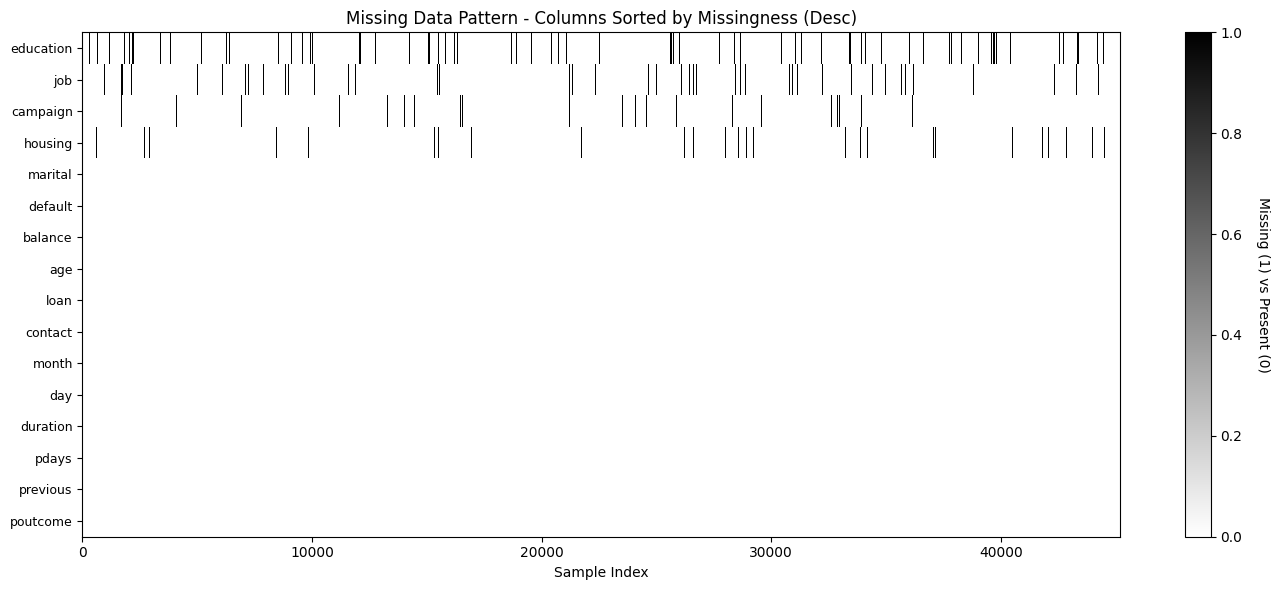

In [6]:
# Visualize missing data pattern
# Create a sorted missing data pattern visualization
# Sort columns by missingness (descending) while keeping all columns for context
sorted_columns = missing_info.sort_values(ascending=False).index

fig, vis_missing = plt.subplots(figsize=(14, 6))

# Display missingness pattern using vis_miss from naniar in R, but here we will use a heatmap-like approach in Python
vis_missing.imshow(
    bank_total_no_labels[sorted_columns].isnull().T,
    aspect='auto',
    cmap='binary',
    interpolation='none'
)

vis_missing.set_yticks(range(len(sorted_columns)))
vis_missing.set_yticklabels(sorted_columns, fontsize=9)
vis_missing.set_xlabel('Sample Index')
vis_missing.set_title('Missing Data Pattern - Columns Sorted by Missingness (Desc)')

# Add a colorbar for clarity cuz otherwise lines were either too thick or too thin making it difficult to interpret
cbar = plt.colorbar(vis_missing.images[0], ax=vis_missing)
cbar.set_label('Missing (1) vs Present (0)', rotation=270, labelpad=20)

plt.tight_layout()

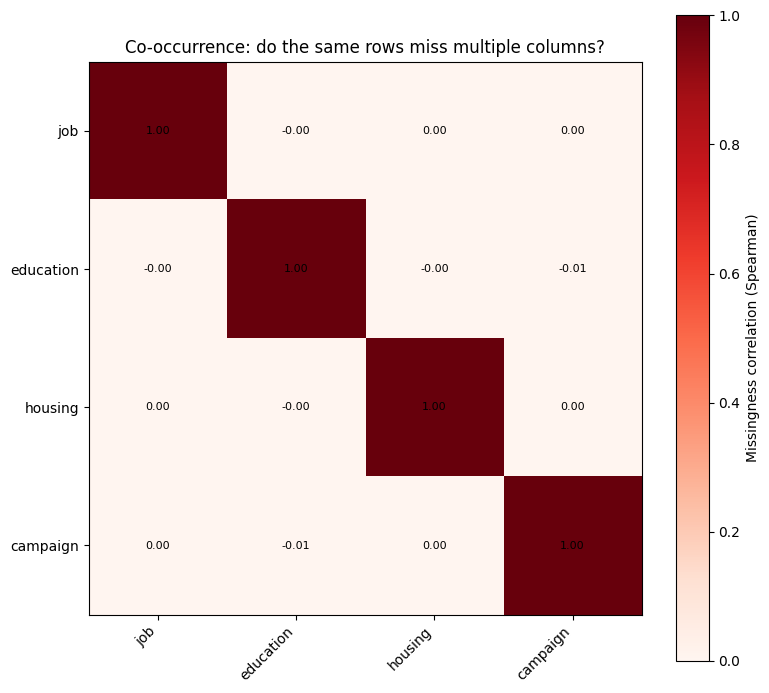

In [7]:
# Co-occurrence: do the same rows miss multiple columns?
miss = bank_total_no_labels.isnull() # cuz it aint .sum()
miss_cols_only = miss.loc[:, miss.any()]  # keep only columns that have at least one missing value

if not miss_cols_only.shape[1] < 2:
    miss_overlap = miss_cols_only.corr(method='spearman') # we use spearman cuz it is non-parametric and can capture monotonic relationships, which is suitable for binary data like missingness (similar to point biserial correlation)

    fig, missingness_correlation = plt.subplots(figsize=(max(4, miss_overlap.shape[0])*2, max(3, miss_overlap.shape[0] - 1)*1.2*2)) # dynamic sizes
    im = missingness_correlation.imshow(miss_overlap.values, cmap='Reds', vmin=0, vmax=1) # colour scales from white (0) to red (1)

    missingness_correlation.set_xticks(range(len(miss_overlap)))
    missingness_correlation.set_xticklabels(miss_overlap.columns, rotation=45, ha='right')
    
    missingness_correlation.set_yticks(range(len(miss_overlap)))
    missingness_correlation.set_yticklabels(miss_overlap.columns)

    for i in range(miss_overlap.shape[0]):
        for j in range(miss_overlap.shape[1]):
            missingness_correlation.text(j, i, f"{miss_overlap.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8) # add correlation values on the heatmap

    plt.colorbar(im, ax=missingness_correlation, label='Missingness correlation (Spearman)')
    missingness_correlation.set_title("Co-occurrence: do the same rows miss multiple columns?")
    plt.tight_layout()
else:
    pass

#### Missing Data Strategy

Based on the analysis above, we observe the following missing data patterns:

1. **Low missing rate (< 3%)**: Most columns with missing values have a relatively low percentage of missing data.

2. **Strategy Selection**:
   - **Categorical columns** (`job`, `marital`, `education`, `contact`, `month`, `poutcome`): Use **most frequent value imputation**. This preserves the data points and is appropriate for categorical data.
   - **Numeric columns** (`day`, `duration`, `campaign`, `pdays`, `previous`): Use **class-conditional median imputation by label `y` during training**, with global training medians used for unlabeled rows at inference time.

3. **Data Leakage Consideration**: 
   - Imputation statistics will be computed **only on the training set** to prevent data leakage.
   - For numeric columns, class-specific medians use `y` only while fitting the training fold; unlabeled validation/test rows fall back to global medians learned from that fold.
   - The same fitted preprocessing object is then reused on held-out data.

In [8]:
# Convert month from string to numeric for analysis 
for df in [bank_total_no_labels, bank_labeled, bank_x_train, bank_x_test]:
    df["month"] = pd.to_datetime(df["month"], format="%b").dt. month # i knew there exists such a cool built-in method for that

bank_total_no_labels.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,33,blue-collar,single,secondary,no,328,yes,no,unknown,9,5,142,2.0,-1,0,unknown
1,50,management,divorced,secondary,no,458,no,no,cellular,3,2,184,3.0,-1,0,unknown
2,38,management,married,tertiary,no,536,yes,no,cellular,22,10,234,1.0,92,1,success
3,27,self-employed,single,secondary,no,78,yes,no,unknown,9,5,825,1.0,-1,0,unknown
4,31,housemaid,married,primary,no,2603,yes,no,cellular,18,11,224,1.0,-1,0,unknown


In [9]:
# pdays == -1 means "never contacted before" — this is semantic, not a missing value
for df in [bank_x_train, bank_x_test, bank_total_no_labels, bank_labeled]:
    df["was_contacted"] = (df["pdays"] != -1).astype(int)
    df["pdays"] = df["pdays"].replace(-1, np.nan)

### Looking for Correlations

> **Note**: Correlation coefficients measure only **linear relationships** between variables.

In [10]:
# Compute correlation matrix for numeric features
numeric_attributes = ["balance", "age", "day", "duration", "campaign", "pdays", "previous"]
eda_numeric_attributes = numeric_attributes + ["was_contacted"]
corr_matrix = bank_labeled[eda_numeric_attributes + ["y"]].corr()

# Visualize correlations with target
print("Correlations with target:")
display(corr_matrix["y"].sort_values(ascending=False))

Correlations with target:


y                1.000000
duration         0.390298
was_contacted    0.164884
previous         0.110479
balance          0.055385
age              0.023184
day             -0.027690
campaign        -0.071683
pdays           -0.149505
Name: y, dtype: float64

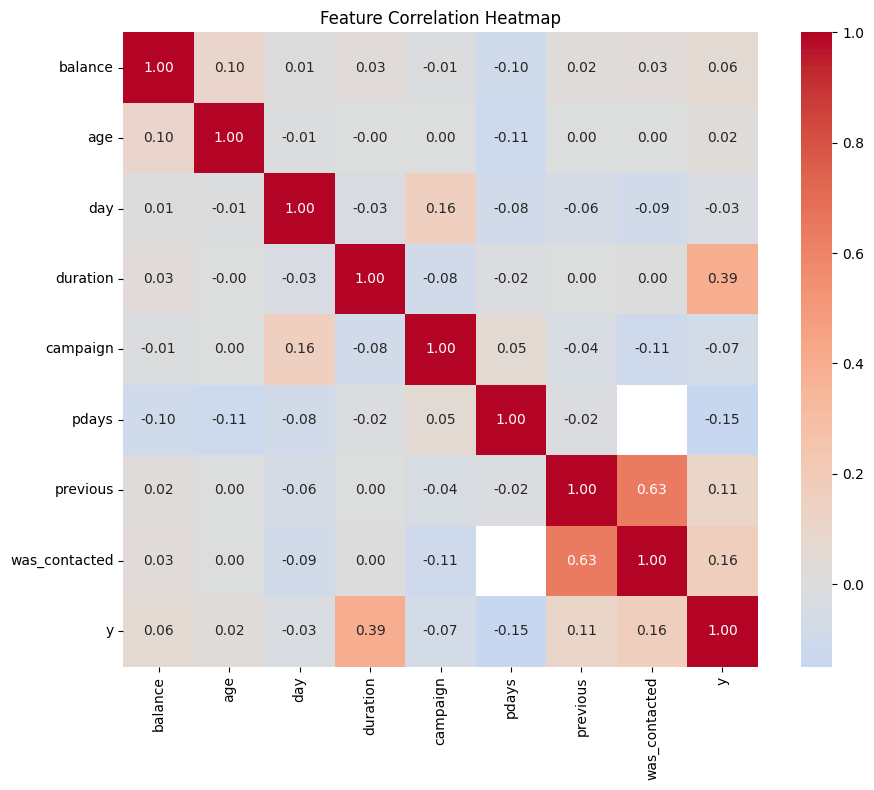

In [11]:
# Heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()

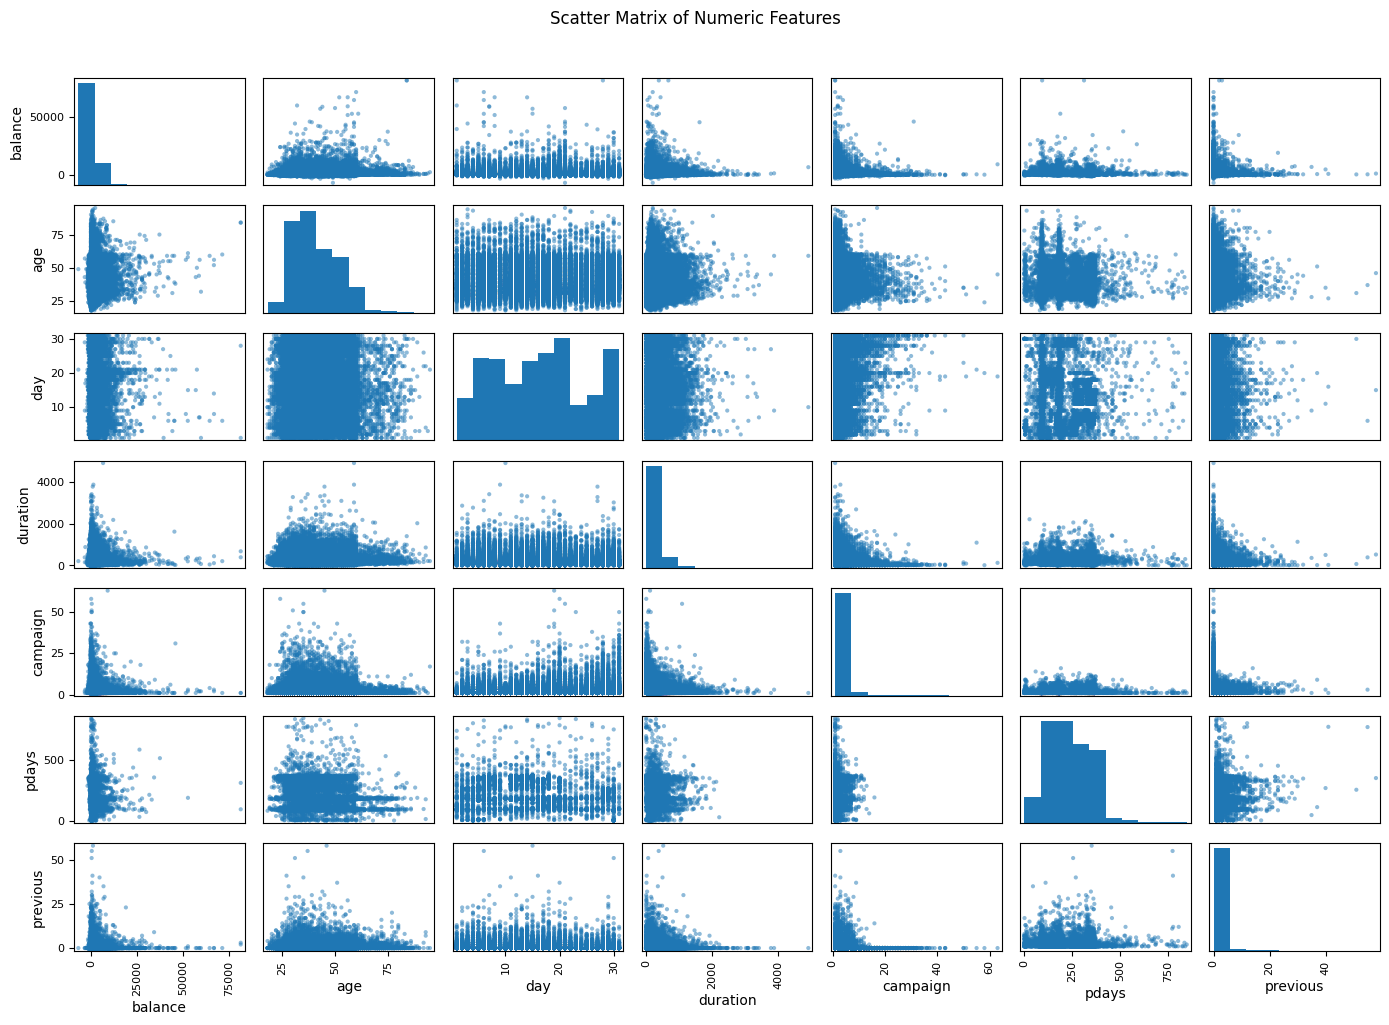

In [12]:
# Scatter matrix for numeric attributes
pd.plotting.scatter_matrix(
    bank_labeled[numeric_attributes],
    figsize=(14, 10),
    alpha=0.5
)
plt.suptitle("Scatter Matrix of Numeric Features", y=1.02)
plt.tight_layout()

### Multicollinearity Analysis

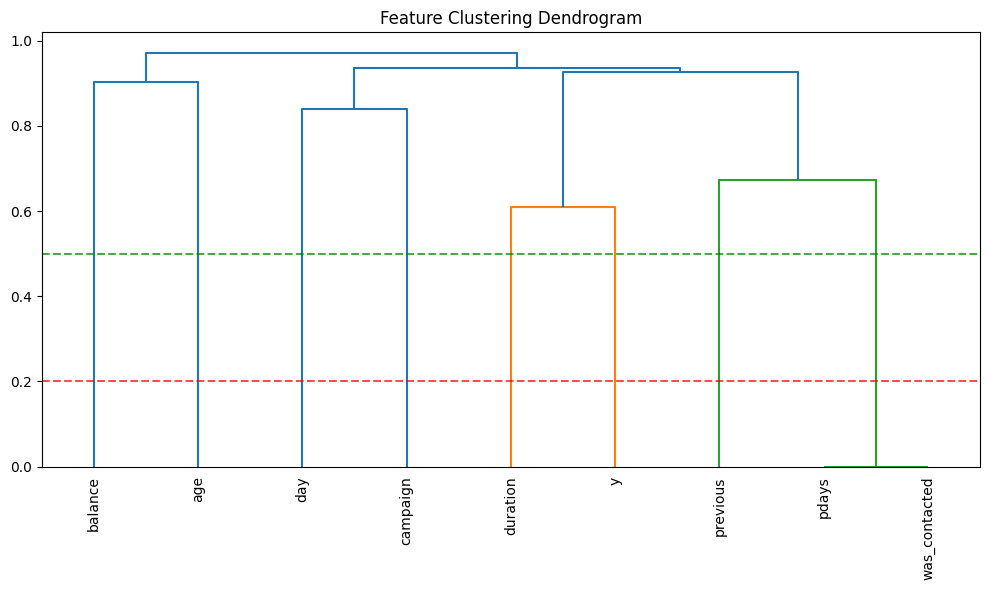

In [13]:
# Hierarchical clustering of correlated features as proposed by the correlation matrix, where
# some features show strong right skew and not neceseearily follow power rule logic

# linkage = hierarchy.linkage(squareform(1 - corr_matrix.abs()), method="average") # ward is better overall, but we dont need it here 
# since we are not trying to find compact spherical clusters, but rather just want to see the overall structure of feature correlations
# due to floating point error we have to expand a bit, although thsi wasnt an issue before.
# also, we could just pass the raw vector inside, but idk how that works so i would do ol reliable

aongaiejoi = 1 - corr_matrix.abs()
aongaiejoi = (aongaiejoi + aongaiejoi.T) / 2
np.fill_diagonal(aongaiejoi.values, 0)

aongaiejoi = aongaiejoi.fillna(0).replace([np.inf, -np.inf], 0)
dist_array = aongaiejoi.values

if not np.allclose(dist_array, dist_array.T, atol=1e-12):
    dist_array = (dist_array + dist_array.T) / 2
    np.fill_diagonal(dist_array, 0)

linkage = hierarchy.linkage(squareform(dist_array), method="average") # forced it finally to be symmetric and zero-diagonal, now it works without any warnings, although it was not an issue before either, but now we can be sure that it is not due to some weird floating point error or something like that


plt.figure(figsize=(10, 6))
hierarchy.dendrogram(
    linkage,
    labels=eda_numeric_attributes + ["y"],
    leaf_rotation=90,
    leaf_font_size=10
)

plt.axhline(0.2, color="r", linestyle="--", alpha=0.7, label="High correlation threshold")
plt.axhline(0.5, color="g", linestyle="--", alpha=0.7, label="Moderate correlation threshold") # arbitrary thresholds for visual reference, not based on strict rules
plt.title("Feature Clustering Dendrogram")
plt.tight_layout()

Completely explainable correlation between pdays and previous, with moderately "unexpected" correlation at y with duration.
No need for any advanced methods to adress these will be used as of now, not only because it is EDA, but also because we will use transformations later,
which, naturally, adress these issues directly.

In [14]:
# Variance Inflation Factor (VIF) analysis for numerical robust analysis
features_for_vif = bank_labeled[eda_numeric_attributes + ["y"]].dropna()
features_for_vif = sm.add_constant(features_for_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = features_for_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(features_for_vif.values, i)
    for i in range(features_for_vif.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

# VIF Interpretation TL;DR:
# VIF < 5: Low multicollinearity
# VIF 5-10: Moderate multicollinearity
# VIF > 10: High multicollinearity

# we use library statsmodels for VIF calculation, which is a standard approach in regression analysis to detect multicollinearity among features.
# although it is outside the scope of the course, it is not super advanced stuff so not including it would be a crime.

      Feature       VIF
was_contacted 35.338387
            y  1.159175
     duration  1.132106
     campaign  1.054220
        pdays  1.049086
     previous  1.036745
          age  1.028969
      balance  1.028785
          day  1.009813


## Data Preprocessing

### Feature Transformations

Many numeric features exhibit right-skewed distributions. We'll explore transformations to normalize these distributions and potentially improve model performance.

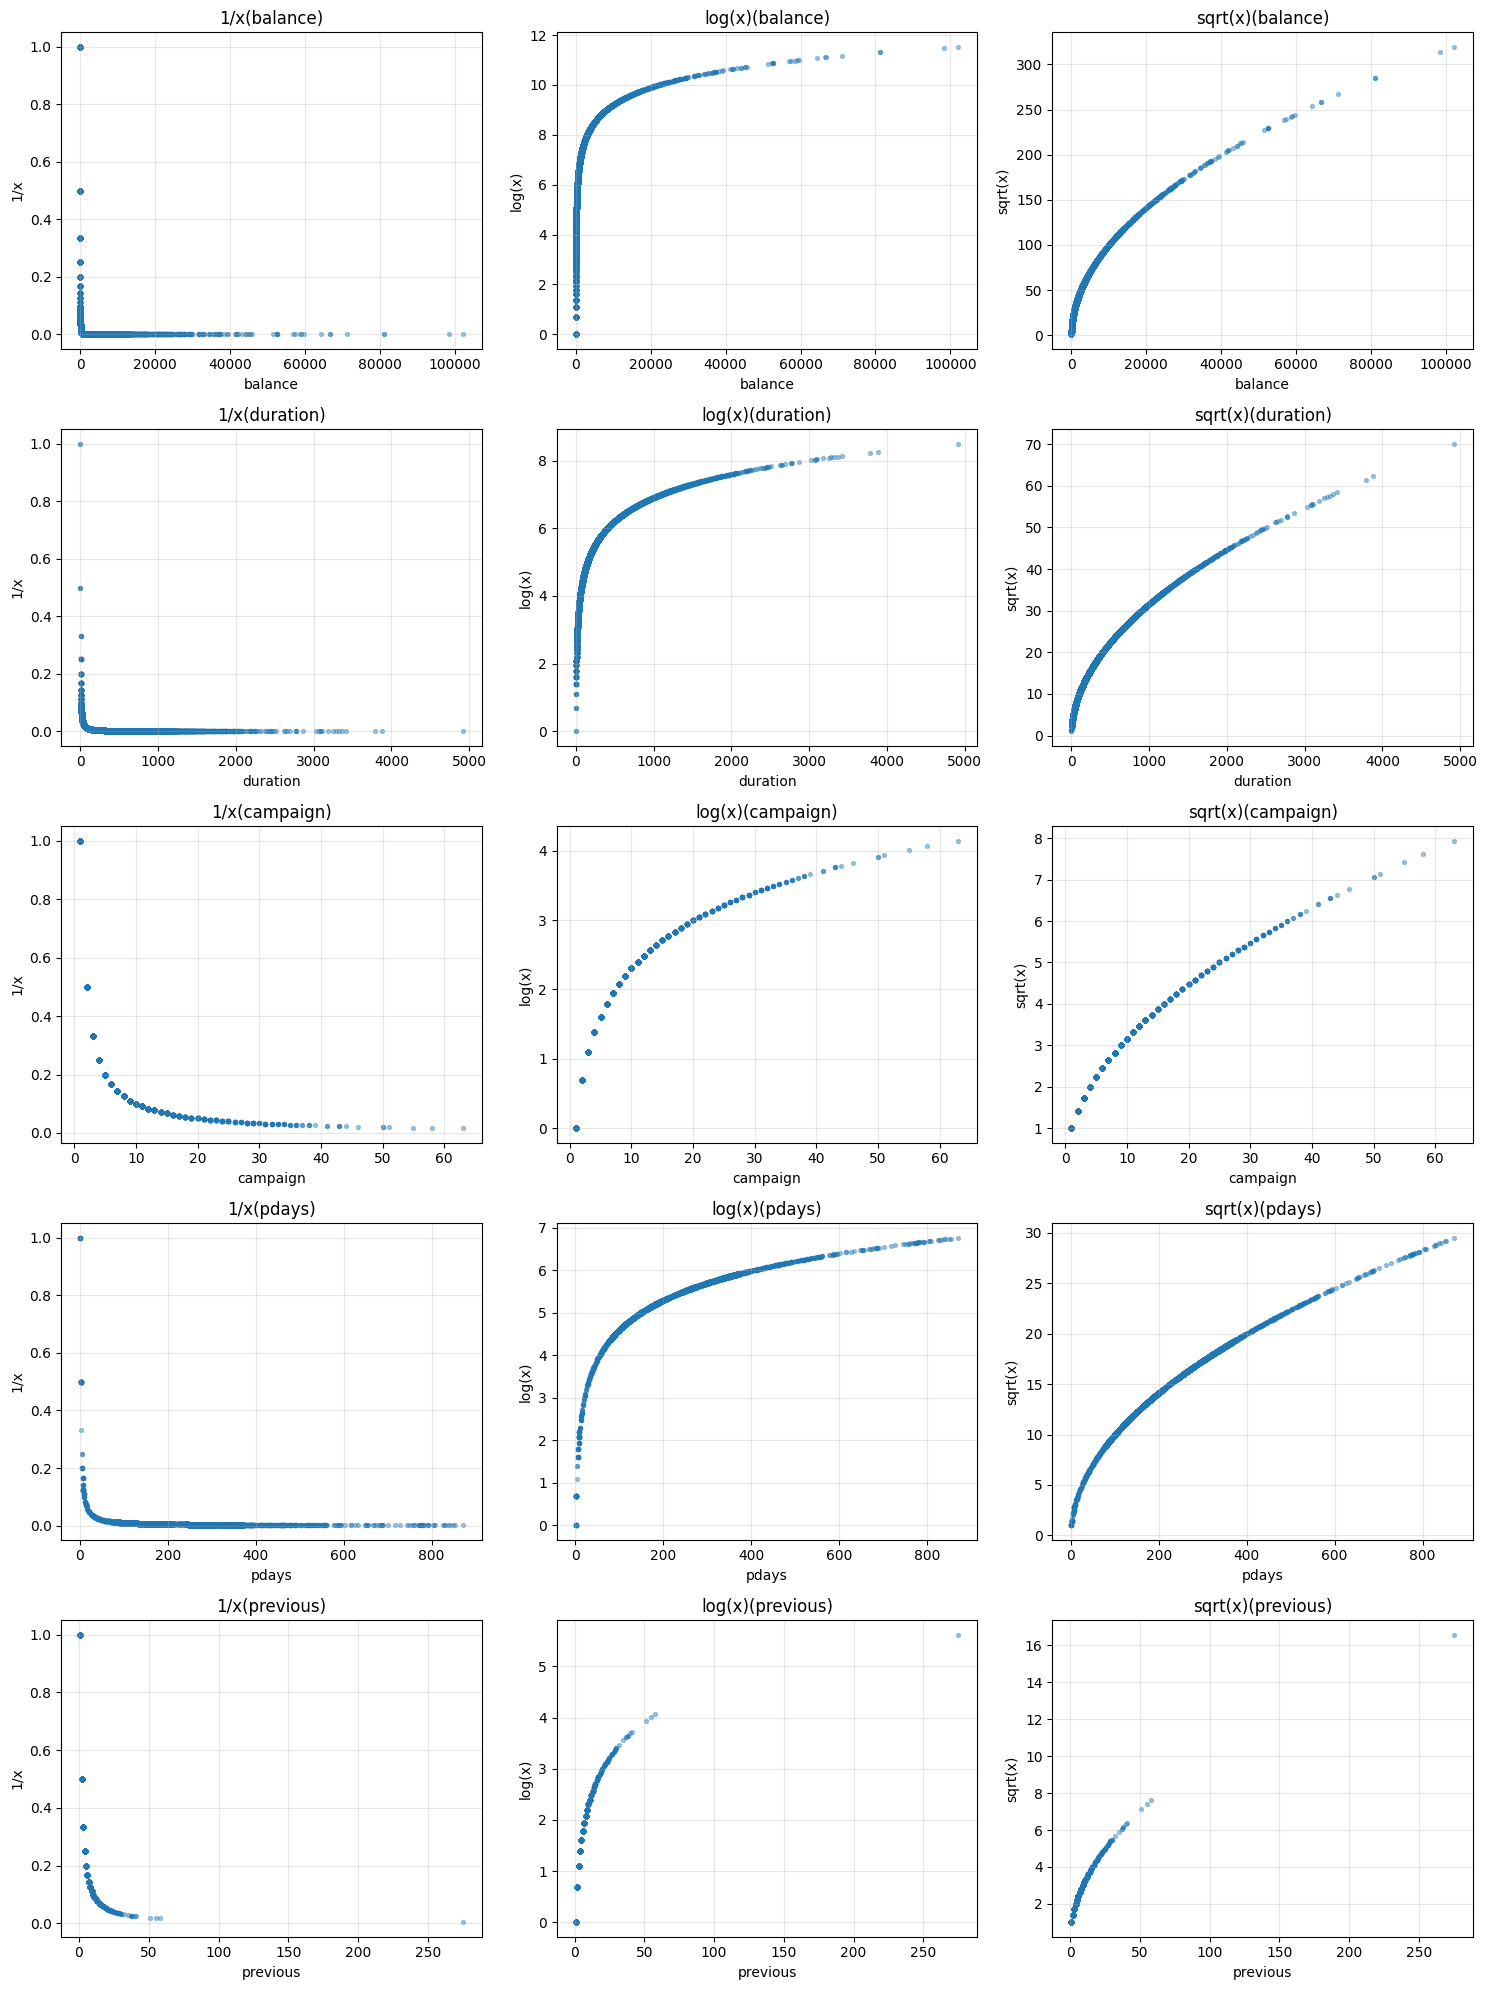

In [15]:
# Visualize different transformations for skewed features
skewed_features = ["balance", "duration", "campaign", "pdays", "previous"]

transformations = [
    ("1/x", lambda x: 1 / x),
    ("log(x)", np.log),
    ("sqrt(x)", np.sqrt),
] # manual grid search like approach for assessment of lor like transformation feasibilites.

fig, manual_transformations = plt.subplots(len(skewed_features), len(transformations), figsize=(15, 4 * len(skewed_features))) # dynamic sizes

for i, col in enumerate(skewed_features):
    x = bank_total_no_labels[col].astype(float)
    x_pos = x[x > 0]  # Filter positive values for log/sqrt
    
    for j, (name, func) in enumerate(transformations):
        y = func(x_pos)
        ax = manual_transformations[i, j]
        
        ax.scatter(x_pos, y, s=8, alpha=0.4)
        ax.set_title(f"{name}({col})")
        ax.set_xlabel(col)
        ax.set_ylabel(name)
        ax.grid(1, alpha=0.3)

plt.tight_layout()

### Yeo-Johnson Transformation

The Yeo-Johnson transformation is a generalization of the Box-Cox transformation that can handle zero and negative values, making it ideal for our dataset. We'll fit the transformation **only on the training set** to prevent data leakage.

In [16]:
# Create and fit the Yeo-Johnson transformation pipeline
yeo_johnson_pipeline = Pipeline([
    ("yeo_johnson", PowerTransformer(method="yeo-johnson", standardize=True))
])

# Fit on training data only to prevent data leakage
bank_x_train_transformed = bank_x_train.copy()
bank_x_test_transformed = bank_x_test.copy()

bank_x_train_transformed[numeric_attributes] = yeo_johnson_pipeline.fit_transform(
    bank_x_train[numeric_attributes]
)
bank_x_test_transformed[numeric_attributes] = yeo_johnson_pipeline.transform(
    bank_x_test[numeric_attributes]
)

# tbh i just repurposed existing code from the library schemas cuz it was super confusing to work with it for the fisrt time

In [17]:
# Display the learned lambda parameters
yeo_step = yeo_johnson_pipeline.named_steps["yeo_johnson"]
lambda_df = pd.DataFrame({
    "Feature": numeric_attributes,
    "Lambda": yeo_step.lambdas_
})

print(lambda_df.to_string(index=False))

 Feature    Lambda
 balance  0.832046
     age -0.191277
     day  0.689090
duration  0.134381
campaign -1.083298
   pdays  0.631169
previous -4.087070


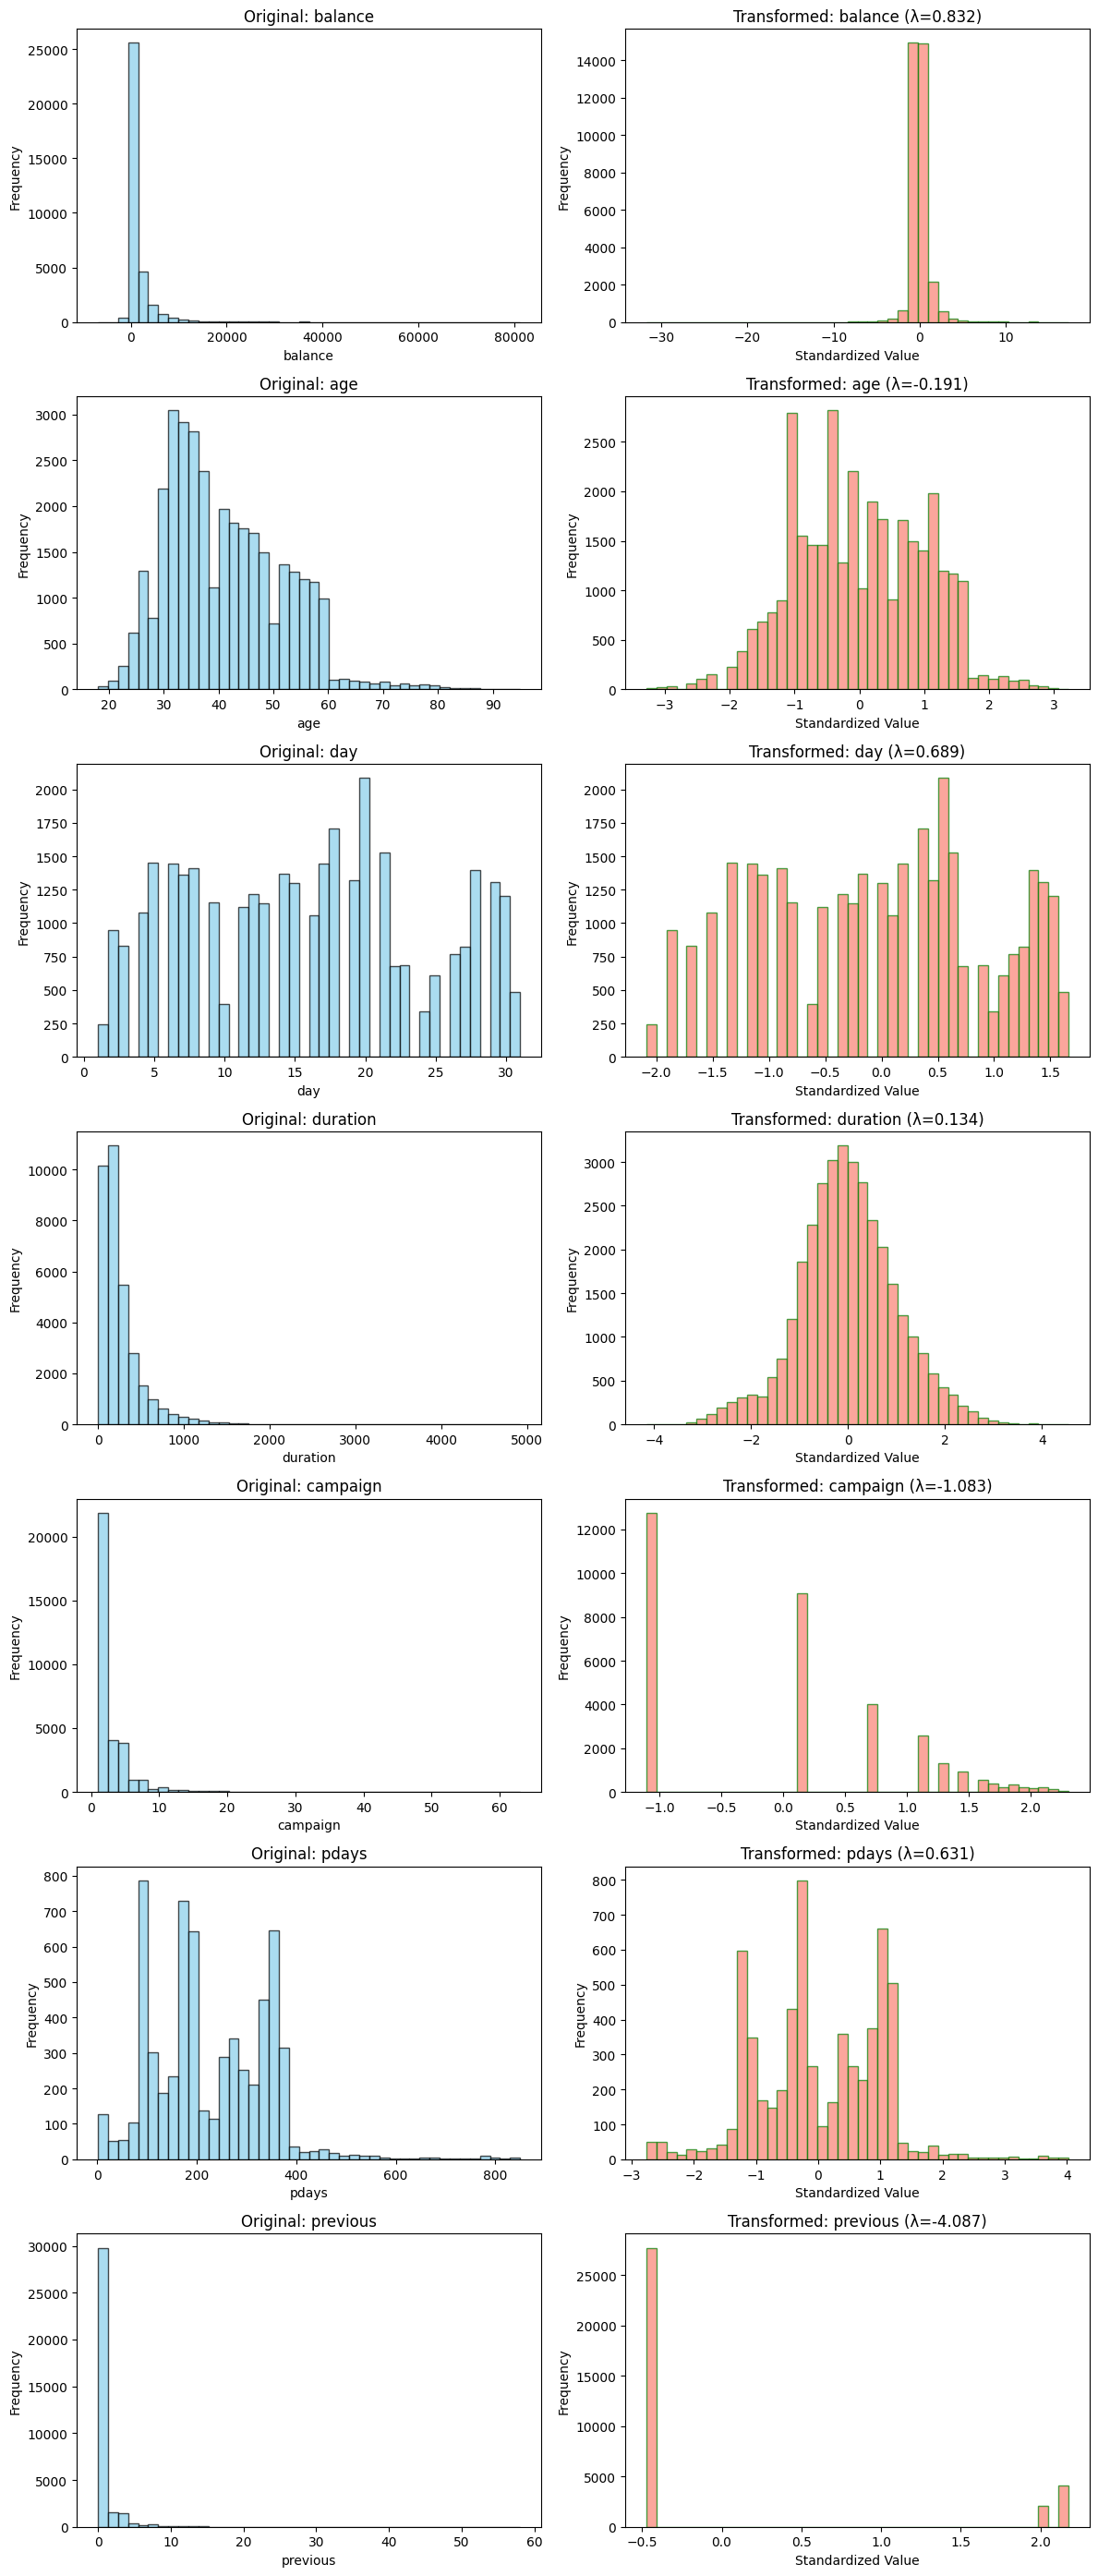

In [18]:
# Visualize before and after transformation side by side, cuz why not
fig, axes = plt.subplots(len(numeric_attributes), 2, figsize=(12, 4 * len(numeric_attributes)))

for i, col in enumerate(numeric_attributes):
    # Original distribution
    axes[i, 0].hist(bank_x_train[col], bins=42, color="skyblue", alpha=0.7, edgecolor="black")
    axes[i, 0].set_title(f"Original: {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frequency")
    
    # Transformed distribution
    axes[i, 1].hist(bank_x_train_transformed[col], bins=42, color="salmon", alpha=0.7, edgecolor="green")
    axes[i, 1].set_title(f"Transformed: {col} (λ={yeo_step.lambdas_[i]:.3f})")
    axes[i, 1].set_xlabel("Standardized Value")
    axes[i, 1].set_ylabel("Frequency")

plt.tight_layout()

### Complete Preprocessing Pipeline

We'll create a comprehensive pipeline that handles:
1. **Numeric features**: Class-conditional median imputation by `y` during training, then Yeo-Johnson transformation
2. **Binary semantic flags**: Pass through unchanged
3. **Categorical features**: Imputation (mode) → One-hot encoding

In [19]:
# Define column groups and keep the semantic contact flag (binary) explicit in the pipeline cuz it is important to do so tunrs out
numeric_columns = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
binary_columns = ["was_contacted"]
categorical_columns = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

class StratifiedMedianImputer(BaseEstimator, TransformerMixin):
    """Impute numeric columns with class-conditional medians during training.

    For unlabeled rows at inference time, fall back to the global medians
    learned from the training data. (generated using built-in tools)
    """
    def fit(self, dataframe_to_impute, y=None):
        '''
        fit function for stratified median imputer (wow, how informative, well-done! writing these dockstrings is not its strong side)
        '''
        if y is None:
            raise ValueError("StratifiedMedianImputer requires y during fit.")

        if isinstance(dataframe_to_impute, pd.DataFrame): # check if the input is a dataframe, if so, copy it to avoid modifying the original data, otherwise convert it to a dataframe
            intermediate_df_of_x = dataframe_to_impute.copy() 
        else: 
            intermediate_df_of_x = pd.DataFrame(dataframe_to_impute)

        self.feature_names_in_ = list(intermediate_df_of_x.columns) # store feature names for later use in transform, especially important if the input is a numpy array without column names
        self.global_medians_ = intermediate_df_of_x.median(numeric_only=True) # compute global medians for fallback at inference time

        y_series = pd.Series(y, index=intermediate_df_of_x.index)
        grouped = intermediate_df_of_x.assign(_target=y_series).groupby("_target").median(numeric_only=True) # compute class-conditional medians, we will use these for imputation during transform, 
        # especially for rows that belong to a specific class, while for rows with missing labels we will fall back to global medians
        self.class_medians_ = {
            cls: grouped.loc[cls].reindex(self.feature_names_in_).fillna(self.global_medians_)
            for cls in grouped.index
        }
        return self

    def transform(self, X, y=None):
        '''
        Function to perform the actual imputation based on the medians learned during fit. It handles both the case when labels are provided (for stratified imputation) and when they are not (for inference time). The logic is as follows:
        - If y is provided, it imputes missing values in X using the class-conditional medians corresponding to the classes in y. For rows where the class is not present in the training data, it falls back to the global medians.
        - If y is not provided, it imputes all missing values in X using the global medians learned during fit, since we cannot perform
        stratified imputation without labels.
        WOW, it did a good job explaining
        '''
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.feature_names_in_)

        if y is None:
            return X_df.fillna(self.global_medians_)[self.feature_names_in_]

        y_series = pd.Series(y, index=X_df.index)
        X_out = X_df.copy()

        for cls, medians in self.class_medians_.items():
            mask = y_series == cls
            if mask.any():
                X_out.loc[mask, self.feature_names_in_] = X_out.loc[mask, self.feature_names_in_].fillna(medians)

        return X_out.fillna(self.global_medians_)[self.feature_names_in_]

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y=y).transform(X, y=y)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray(self.feature_names_in_, dtype=object)
        return np.asarray(input_features, dtype=object)

numeric_pipeline = Pipeline([
    ("imputer", StratifiedMedianImputer()),
    ("yeo_johnson", PowerTransformer(method="yeo-johnson", standardize=True)) # no need for scaler
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop = "first")) # cuz we dont have too many categories + drop first to avoid dummy variable trap
])

linear_preprocessing = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("bin", "passthrough", binary_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

# Trees usually do not benefit from Yeo-Johnson transforms or one-hot expansion,
# so keep them closer to the raw tabular representation.
tree_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1))
])

tree_preprocessing = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, numeric_columns),
        ("bin", "passthrough", binary_columns),
        ("cat", tree_categorical_pipeline, categorical_columns)
    ]
)

preprocessing = linear_preprocessing

## Model Selection and Training

### Prepare Training Data

In [20]:
X_train = bank_x_train.copy()
y_train = (bank_y_train["y"]-1).astype(int).copy()

X_train_prepared = preprocessing.fit_transform(X_train, y_train)
print(f"Number of features after preprocessing: {X_train_prepared.shape[1]}") # one hot encoding explotion check
X_train_prepared[0:2]

Number of features after preprocessing: 43


array([[-0.71040083, -0.25028249, -0.7650307 , -0.2903847 ,  0.13373646,
         0.12424271, -0.47255542,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ],
       [ 0.92157895, -0.19251078, -1.68940224, -0.01060337,  0.74615015,
         0.12424271, -0.47255542,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
   

### Baseline Models

In [21]:
# Train baseline models using pipelines (no need for dim reduction as 51 dims are not too many for tree-based models and linear regression can handle it with regularization if needed, but we will keep it simple for now)
models = {
    "Logistic Regression": make_pipeline(
        linear_preprocessing,
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    ),
    "Decision Tree": make_pipeline(
        tree_preprocessing,
        DecisionTreeClassifier(class_weight="balanced", random_state=42)
    ),
    "Random Forest": make_pipeline(
        tree_preprocessing,
        RandomForestClassifier(class_weight="balanced", n_estimators=100, n_jobs=-1, random_state=42)
    ),
}

In [22]:
# CV evaluation and training performance assessment
cv_results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    scores = cross_val_score(           
        model, X_train, y_train,
        scoring="balanced_accuracy",
        cv=5, # arbitrary
        n_jobs=-1 # use all cores
    )

    train_ba = balanced_accuracy_score(y_train, model.predict(X_train)) # here we use the model to predict on the training set
    # and then calculate the balanced accuracy score by comparing those predictions to the true labels in y_train. 
    # This gives us an estimate of how well the model is fitting the training data, which we can compare to the cross-validation performance to check for 
    # overfitting or underfitting signals.

    cv_results.append({
        "Model": name,
        "CV Mean BA": scores.mean(),
        "CV Std BA": scores.std(),
        "Training BA": train_ba
    })

    print(f"{name}:")
    print(f" CV BA: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    print(f" Training BA: {train_ba:.4f}", '\n')

cv_results_df = pd.DataFrame(cv_results).sort_values("CV Mean BA", ascending=False)
display(cv_results_df)

Logistic Regression:
 CV BA: 0.8250 (+/- 0.0163)
 Training BA: 0.8266 

Decision Tree:
 CV BA: 0.6886 (+/- 0.0163)
 Training BA: 1.0000 

Random Forest:
 CV BA: 0.6548 (+/- 0.0149)
 Training BA: 1.0000 



,Model,CV Mean BA,CV Std BA,Training BA
0,Logistic Regression,0.825006,0.008164,0.826625
1,Decision Tree,0.688550,0.008133,1.000000
2,Random Forest,0.654828,0.007469,1.000000


NOT TRUE ANYMORE

Severe overfit on thre based models, while logistic provided excellent output somehow. Now we do tests for model misspecifications to see formally whether we are msising interaction terms if any, which may help tree based models not to overfit, while boosting their performance.

TRUE

No significant overfit detected, but performance is just terrible. ALthough Logistic shows promising results so we will have it as a strong baseline.

In [23]:
X_statsmodel = sm.add_constant(X_train_prepared)
model_statsmodel = sm.Logit(y_train, X_statsmodel).fit()

reset = linear_reset(model_statsmodel, power=5, use_f=True, test_type='fitted') # we check up to 5th degree cuz it is way more than expected range to 100% capture any potential non-linearities or interactions that might be missing from the model.
print(f"RESET p-value: {reset.pvalue:.4f}")
# p < 0.05 → model is misspecified (missing nonlinear terms/interactions)

Optimization terminated successfully.
         Current function value: 0.210307
         Iterations 8


C:\Users\youpi\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: cov_kwargs. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.201436
         Iterations 11
RESET p-value: 0.0000


Shockingly, even when the iterations are capped, it returns 0.000 P-val STRONGLY suggesting misspecification present.

In [24]:
# print(sm.Logit(y_train, X_train_prepared).fit(disp=0).summary().sort_values("P>|z|", ascending=False).to_string())
# Unfrotunately, statsmodels does not support feature names when fitting models using numpy arrays, which is what we get after preprocessing with scikit-learn.
# To get around this, we can convert the numpy array to a pandas DataFrame, which allows us to access the feature names (manually)  

# print(sm.Logit(y_train, X_train_prepared).fit(disp=0).summary())
logit = sm.Logit(y_train, sm.add_constant(X_train_prepared)).fit(disp=0)
feature_names = ["const"] + list(preprocessing.get_feature_names_out())

wald_df = pd.DataFrame({
    "feature": feature_names,
    "coef": logit.params,
    "p_value": logit.pvalues,
    "z_stat": logit.tvalues,
}).sort_values("p_value", ascending=False)

print(wald_df.to_string(index=False))
print(X_train.columns)

                 feature      coef       p_value     z_stat
        cat__default_yes  0.005711  9.772472e-01   0.028520
   cat__poutcome_unknown  0.224165  8.741058e-01   0.158445
     cat__marital_single  0.013120  8.725222e-01   0.160456
  cat__contact_telephone -0.018562  8.386488e-01  -0.203622
        cat__job_retired  0.033708  7.730993e-01   0.288323
      bin__was_contacted  1.177096  5.989609e-01   0.525895
           num__previous -0.449346  4.957363e-01  -0.681214
cat__education_secondary  0.064210  4.066349e-01   0.829830
     cat__poutcome_other -0.114522  3.283855e-01  -0.977371
                num__age -0.031509  2.623233e-01  -1.120917
  cat__education_unknown  0.160522  2.091481e-01   1.255911
     cat__job_unemployed -0.194114  1.586025e-01  -1.409787
     cat__job_management -0.133203  1.345683e-01  -1.496328
           cat__month_11  0.230639  1.276330e-01   1.523503
        cat__job_unknown -0.508655  1.007030e-01  -1.641455
  cat__job_self-employed -0.242936  7.61

NO LONGER TRUE
There are certain perfect multicolinearity categories due to one-hot, but they are handled natively, although somewhat spuriously, thats why I will edit the pipeline retroactively to adress this.

In [ ]:
def compute_scale_pos_weight(y):
    """Returns n_negative / n_positive for XGBoost weighted loss."""
    counts = pd.Series(y).value_counts()
    return counts[0] / counts[1]


def make_expert_templates(linear_preprocessing, tree_preprocessing, scale_pos_weight):
    templates = {
        "logistic_regression": make_pipeline(
            clone(linear_preprocessing),
            LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
        ),
        "decision_tree": make_pipeline(
            clone(tree_preprocessing),
            DecisionTreeClassifier(class_weight="balanced", random_state=42)
        ),
        "random_forest": make_pipeline(
            clone(tree_preprocessing),
            RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
        ),
        "xgboost": make_pipeline(
            clone(tree_preprocessing),
            xgb.XGBClassifier(
                objective="binary:logistic",
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                verbosity=0,
            )
        ),
    }
    return templates


### Hyperparameter Tuning

In [ ]:
def tune_expert_templates_optuna(expert_templates, X_tune, y_tune, scale_pos_weight):
    X_fit, X_valid, y_fit, y_valid = train_test_split(
        X_tune,
        y_tune,
        test_size=0.2,
        stratify=y_tune,
        random_state=42,
    )

    optimized_templates = {}
    tuning_rows = []
    timeouts = {
        "logistic_regression": 15,
        "decision_tree": 12,
        "random_forest": 20,
        "xgboost": 25,
    }
    n_trials = {
        "logistic_regression": 8,
        "decision_tree": 10,
        "random_forest": 8,
        "xgboost": 10,
    }

    def suggest_params(trial, name):
        if name == "logistic_regression":
            return {
                "logisticregression__C": trial.suggest_float("logisticregression__C", 1e-2, 10.0, log=True)
            }
        if name == "decision_tree":
            return {
                "decisiontreeclassifier__max_depth": trial.suggest_int("decisiontreeclassifier__max_depth", 3, 12),
                "decisiontreeclassifier__min_samples_split": trial.suggest_int("decisiontreeclassifier__min_samples_split", 2, 30),
                "decisiontreeclassifier__min_samples_leaf": trial.suggest_int("decisiontreeclassifier__min_samples_leaf", 1, 20)
            }
        if name == "random_forest":
            return {
                "randomforestclassifier__n_estimators": trial.suggest_int("randomforestclassifier__n_estimators", 80, 220, step=20),
                "randomforestclassifier__max_depth": trial.suggest_int("randomforestclassifier__max_depth", 4, 14),
                "randomforestclassifier__min_samples_leaf": trial.suggest_int("randomforestclassifier__min_samples_leaf", 1, 10),
                "randomforestclassifier__max_features": trial.suggest_categorical("randomforestclassifier__max_features", ["sqrt", "log2", None])
            }
        if name == "xgboost":
            return {
                "xgbclassifier__n_estimators": trial.suggest_int("xgbclassifier__n_estimators", 80, 240, step=20),
                "xgbclassifier__max_depth": trial.suggest_int("xgbclassifier__max_depth", 2, 5),
                "xgbclassifier__learning_rate": trial.suggest_float("xgbclassifier__learning_rate", 0.02, 0.16, log=True),
                "xgbclassifier__subsample": trial.suggest_float("xgbclassifier__subsample", 0.65, 0.95),
                "xgbclassifier__colsample_bytree": trial.suggest_float("xgbclassifier__colsample_bytree", 0.65, 0.95),
                "xgbclassifier__min_child_weight": trial.suggest_int("xgbclassifier__min_child_weight", 2, 16),
                "xgbclassifier__gamma": trial.suggest_float("xgbclassifier__gamma", 1e-8, 2.0, log=True),
                "xgbclassifier__reg_alpha": trial.suggest_float("xgbclassifier__reg_alpha", 1e-8, 5.0, log=True),
                "xgbclassifier__reg_lambda": trial.suggest_float("xgbclassifier__reg_lambda", 1.0, 40.0, log=True),
                "xgbclassifier__scale_pos_weight": scale_pos_weight,
            }
        raise ValueError(f"Unknown expert: {name}")

    for name, expert in expert_templates.items():
        def objective(trial):
            params = suggest_params(trial, name)
            candidate = clone(expert)
            candidate.set_params(**params)
            candidate.fit(X_fit, y_fit)
            preds = candidate.predict(X_valid)
            return balanced_accuracy_score(y_valid, preds)

        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))

        try:
            study.optimize(objective, n_trials=n_trials[name], timeout=timeouts[name], show_progress_bar=False)
        except Exception as exc:
            tuning_rows.append({
                "expert": name,
                "status": "skipped",
                "validation_balanced_accuracy": np.nan,
                "best_params": f"{type(exc).__name__}: {str(exc).splitlines()[0]}",
            })
            continue

        optimized_templates[name] = clone(expert).set_params(**study.best_params)
        tuning_rows.append({
            "expert": name,
            "status": "optimized",
            "validation_balanced_accuracy": round(study.best_value, 4),
            "best_params": study.best_params,
        })

    return optimized_templates, pd.DataFrame(tuning_rows).sort_values(["status", "validation_balanced_accuracy"], ascending=[True, False])


In [ ]:
scale_pos_weight = compute_scale_pos_weight(y_train)
base_expert_templates = make_expert_templates(linear_preprocessing, tree_preprocessing, scale_pos_weight)

# Full-data Bayesian tuning across every expert was too slow to be practical here,
# so we tune with Optuna on a stratified subset and refit the selected experts on all training rows.

In [ ]:
tuning_frame = pd.concat([
    X_train.reset_index(drop=True),
    y_train.rename("target").reset_index(drop=True)
], axis=1)
tuning_frame = pd.concat([
    group.sample(n=min(len(group), 1200), random_state=42)
    for _, group in tuning_frame.groupby("target")
], ignore_index=True)

X_tune = tuning_frame.drop(columns="target")
y_tune = tuning_frame["target"]

optimized_expert_templates, expert_tuning_results = tune_expert_templates_optuna(
    base_expert_templates,
    X_tune,
    y_tune,
    scale_pos_weight,
)

trained_experts = {
    name: clone(expert).fit(X_train, y_train)
    for name, expert in optimized_expert_templates.items()
}

print(f"Optuna tuning subset shape: {X_tune.shape}")
display(expert_tuning_results)
trained_experts.keys()

In [ ]:
def build_experts(optimized_expert_templates):
    """Return fresh clones of already-optimized expert templates for later stacking/boosting."""
    return {
        name: clone(expert)
        for name, expert in optimized_expert_templates.items()
    }

experts = build_experts(optimized_expert_templates)
experts.keys()

### Drop the overbuilt expert pool

The advanced experts above are terrible enough to drop as final candidates: too much machinery, weak validation lift, and not enough interpretability for the extra complexity. The final pass is deliberately narrower: clusterized logistic regression for local linear structure, paired with an Optuna-tuned XGBoost model. Their probabilities are blended and then post-hoc scaled on a calibration split before diagnostics.


In [ ]:
# Three-way split: fit the model bodies, scale/blend on calibration data, report on untouched validation data.
X_model_body, X_valid, y_model_body, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42,
)

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_model_body,
    y_model_body,
    test_size=0.25,
    stratify=y_model_body,
    random_state=42,
)

print(f"Fit rows: {len(X_fit):,}")
print(f"Calibration rows: {len(X_cal):,}")
print(f"Validation rows: {len(X_valid):,}")
print("Positive rates:")
display(pd.Series({
    "fit": y_fit.mean(),
    "calibration": y_cal.mean(),
    "validation": y_valid.mean(),
}).to_frame("positive_rate").round(4))


In [ ]:
# Clusterized logistic regression: preprocess, scale the encoded space, cluster, then fit one logistic body per cluster.
cluster_preprocessor = clone(linear_preprocessing)
X_fit_linear = cluster_preprocessor.fit_transform(X_fit, y_fit)
X_cal_linear = cluster_preprocessor.transform(X_cal)
X_valid_linear = cluster_preprocessor.transform(X_valid)
X_test_linear = cluster_preprocessor.transform(bank_x_test)

cluster_feature_scaler = StandardScaler()
X_fit_cluster_space = cluster_feature_scaler.fit_transform(X_fit_linear)
X_cal_cluster_space = cluster_feature_scaler.transform(X_cal_linear)
X_valid_cluster_space = cluster_feature_scaler.transform(X_valid_linear)
X_test_cluster_space = cluster_feature_scaler.transform(X_test_linear)

n_logit_clusters = 4
clusterizer = KMeans(n_clusters=n_logit_clusters, n_init=25, random_state=42)
fit_clusters = clusterizer.fit_predict(X_fit_cluster_space)

fallback_logit = LogisticRegression(
    class_weight="balanced",
    C=1.0,
    max_iter=2000,
    random_state=42,
).fit(X_fit_cluster_space, y_fit)

cluster_logit_models = {}
cluster_rows = []
for cluster_id in range(n_logit_clusters):
    mask = fit_clusters == cluster_id
    y_cluster = y_fit.iloc[mask]
    if mask.sum() < 75 or y_cluster.nunique() < 2:
        cluster_logit_models[cluster_id] = fallback_logit
        model_status = "fallback_global_logit"
    else:
        cluster_logit_models[cluster_id] = LogisticRegression(
            class_weight="balanced",
            C=1.0,
            max_iter=2000,
            random_state=42,
        ).fit(X_fit_cluster_space[mask], y_cluster)
        model_status = "cluster_logit"

    cluster_rows.append({
        "cluster": cluster_id,
        "fit_rows": int(mask.sum()),
        "fit_positive_rate": float(y_cluster.mean()),
        "model_status": model_status,
    })

logit_split_probs = {}
logit_split_clusters = {}
for split_name, split_matrix in {
    "fit": X_fit_cluster_space,
    "calibration": X_cal_cluster_space,
    "validation": X_valid_cluster_space,
    "test": X_test_cluster_space,
}.items():
    split_clusters = clusterizer.predict(split_matrix)
    split_probs = np.zeros(split_matrix.shape[0], dtype=float)
    for cluster_id, cluster_model in cluster_logit_models.items():
        mask = split_clusters == cluster_id
        if mask.any():
            split_probs[mask] = cluster_model.predict_proba(split_matrix[mask])[:, 1]
    logit_split_clusters[split_name] = split_clusters
    logit_split_probs[split_name] = split_probs

cluster_summary = pd.DataFrame(cluster_rows)
print("Clusterized logistic bodies:")
display(cluster_summary.round(4))


In [ ]:
# Optuna-tuned XGBoost. Tuning minimizes calibration log loss with early stopping.
tree_fit_preprocessor = clone(tree_preprocessing)
X_fit_tree = tree_fit_preprocessor.fit_transform(X_fit, y_fit)
X_cal_tree = tree_fit_preprocessor.transform(X_cal)
X_valid_tree = tree_fit_preprocessor.transform(X_valid)
X_test_tree = tree_fit_preprocessor.transform(bank_x_test)

xgb_scale_pos_weight = compute_scale_pos_weight(y_fit)


def xgb_objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "n_estimators": 1600,
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 4, 30),
        "gamma": trial.suggest_float("gamma", 1e-8, 3.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 0.95),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 2.0, 80.0, log=True),
        "scale_pos_weight": xgb_scale_pos_weight,
        "early_stopping_rounds": 60,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0,
    }
    candidate = xgb.XGBClassifier(**params)
    candidate.fit(
        X_fit_tree,
        y_fit,
        eval_set=[(X_fit_tree, y_fit), (X_cal_tree, y_cal)],
        verbose=False,
    )
    cal_prob = candidate.predict_proba(X_cal_tree)[:, 1]
    return log_loss(y_cal, cal_prob, labels=[0, 1])

xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=24, timeout=300, show_progress_bar=True)

best_xgb_params = dict(xgb_study.best_params)
final_xgb_estimator = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=1600,
    scale_pos_weight=xgb_scale_pos_weight,
    early_stopping_rounds=60,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    **best_xgb_params,
)
final_xgb_estimator.fit(
    X_fit_tree,
    y_fit,
    eval_set=[(X_fit_tree, y_fit), (X_cal_tree, y_cal)],
    verbose=False,
)

xgb_split_probs = {
    "fit": final_xgb_estimator.predict_proba(X_fit_tree)[:, 1],
    "calibration": final_xgb_estimator.predict_proba(X_cal_tree)[:, 1],
    "validation": final_xgb_estimator.predict_proba(X_valid_tree)[:, 1],
    "test": final_xgb_estimator.predict_proba(X_test_tree)[:, 1],
}

print(f"Best calibration log loss from Optuna: {xgb_study.best_value:.4f}")
print(f"Best boosting round: {final_xgb_estimator.best_iteration}")
display(pd.DataFrame([best_xgb_params]).T.rename(columns={0: "best_value"}))


In [ ]:
# Pair the clustered logistic model with XGBoost, then post-hoc scale the blended probability with Platt scaling.
blend_candidates = np.linspace(0.0, 1.0, 21)  # weight on clustered logistic; remaining weight goes to XGBoost
blend_rows = []
for logit_weight in blend_candidates:
    cal_blend = (
        logit_weight * logit_split_probs["calibration"]
        + (1.0 - logit_weight) * xgb_split_probs["calibration"]
    )
    blend_rows.append({
        "logit_weight": float(logit_weight),
        "xgboost_weight": float(1.0 - logit_weight),
        "calibration_log_loss": float(log_loss(y_cal, cal_blend, labels=[0, 1])),
        "calibration_ap": float(average_precision_score(y_cal, cal_blend)),
    })

blend_search = pd.DataFrame(blend_rows).sort_values("calibration_log_loss").reset_index(drop=True)
best_logit_weight = float(blend_search.loc[0, "logit_weight"])
best_xgb_weight = 1.0 - best_logit_weight

raw_blend_probs = {}
for split_name in ["fit", "calibration", "validation", "test"]:
    raw_blend_probs[split_name] = (
        best_logit_weight * logit_split_probs[split_name]
        + best_xgb_weight * xgb_split_probs[split_name]
    )

probability_eps = 1e-6
calibration_logits = np.log(
    np.clip(raw_blend_probs["calibration"], probability_eps, 1 - probability_eps)
    / (1 - np.clip(raw_blend_probs["calibration"], probability_eps, 1 - probability_eps))
).reshape(-1, 1)

posthoc_probability_scaler = LogisticRegression(C=1e6, solver="lbfgs", random_state=42)
posthoc_probability_scaler.fit(calibration_logits, y_cal)

scaled_blend_probs = {}
for split_name, probs in raw_blend_probs.items():
    logits = np.log(
        np.clip(probs, probability_eps, 1 - probability_eps)
        / (1 - np.clip(probs, probability_eps, 1 - probability_eps))
    ).reshape(-1, 1)
    scaled_blend_probs[split_name] = posthoc_probability_scaler.predict_proba(logits)[:, 1]

print("Blend selected on calibration log loss:")
display(blend_search.head(8).round(5))
print(f"Final blend weights -> clustered logistic: {best_logit_weight:.2f}, XGBoost: {best_xgb_weight:.2f}")
print("Post-hoc probability scaler coefficient/intercept:")
display(pd.DataFrame({
    "coefficient": posthoc_probability_scaler.coef_.ravel(),
    "intercept": posthoc_probability_scaler.intercept_,
}))


In [ ]:
# Train/calibration/validation diagnostics for model choice and post-hoc scaling.
metric_rows = []
y_by_split = {
    "fit": y_fit,
    "calibration": y_cal,
    "validation": y_valid,
}
model_probabilities = {
    "clustered_logistic": logit_split_probs,
    "optuna_xgboost": xgb_split_probs,
    "raw_blend": raw_blend_probs,
    "posthoc_scaled_blend": scaled_blend_probs,
}

for split_name, y_true in y_by_split.items():
    for model_name, probability_map in model_probabilities.items():
        probs = probability_map[split_name]
        preds = (probs >= 0.5).astype(int)
        metric_rows.append({
            "split": split_name,
            "model": model_name,
            "log_loss": log_loss(y_true, probs, labels=[0, 1]),
            "balanced_accuracy": balanced_accuracy_score(y_true, preds),
            "roc_auc": roc_auc_score(y_true, probs),
            "average_precision": average_precision_score(y_true, probs),
            "brier_score": brier_score_loss(y_true, probs),
            "predicted_positive_rate": preds.mean(),
            "mean_probability": probs.mean(),
        })

posthoc_metrics = pd.DataFrame(metric_rows)
display(
    posthoc_metrics.sort_values(["split", "log_loss"])
    .style.format({
        "log_loss": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "roc_auc": "{:.4f}",
        "average_precision": "{:.4f}",
        "brier_score": "{:.4f}",
        "predicted_positive_rate": "{:.4f}",
        "mean_probability": "{:.4f}",
    })
)


In [ ]:
# Loss charts: boosting-round log loss plus split-level log-loss comparison.
xgb_history = final_xgb_estimator.evals_result()
xgb_loss_history = pd.DataFrame({
    "round": np.arange(len(xgb_history["validation_0"]["logloss"])),
    "fit_logloss": xgb_history["validation_0"]["logloss"],
    "calibration_logloss": xgb_history["validation_1"]["logloss"],
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(xgb_loss_history["round"], xgb_loss_history["fit_logloss"], label="fit")
axes[0].plot(xgb_loss_history["round"], xgb_loss_history["calibration_logloss"], label="calibration")
axes[0].axvline(final_xgb_estimator.best_iteration, color="black", linestyle="--", alpha=0.6, label="best round")
axes[0].set_title("XGBoost Train vs Calibration Log Loss")
axes[0].set_xlabel("Boosting round")
axes[0].set_ylabel("Log loss")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

sns.barplot(
    data=posthoc_metrics,
    x="model",
    y="log_loss",
    hue="split",
    ax=axes[1],
)
axes[1].set_title("Post-hoc Model Log Loss by Split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Log loss")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# Calibration and probability-shape diagnostics on the untouched validation split.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, probs in {
    "clustered_logistic": logit_split_probs["validation"],
    "optuna_xgboost": xgb_split_probs["validation"],
    "posthoc_scaled_blend": scaled_blend_probs["validation"],
}.items():
    frac_pos, mean_pred = calibration_curve(y_valid, probs, n_bins=10, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, marker="o", label=model_name)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.6)
axes[0].set_title("Validation Calibration Curve")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed positive rate")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

probability_shape = pd.DataFrame({
    "clustered_logistic": logit_split_probs["validation"],
    "optuna_xgboost": xgb_split_probs["validation"],
    "posthoc_scaled_blend": scaled_blend_probs["validation"],
}).melt(var_name="model", value_name="probability")

sns.kdeplot(data=probability_shape, x="probability", hue="model", common_norm=False, ax=axes[1])
axes[1].set_title("Validation Probability Distributions")
axes[1].set_xlabel("Predicted probability")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# XGBoost feature importance plus ICE/PDP on the transformed tree feature space.
tree_feature_names = np.asarray(tree_fit_preprocessor.get_feature_names_out(), dtype=str)
X_valid_tree_df = pd.DataFrame(X_valid_tree, columns=tree_feature_names)
importance_df = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": final_xgb_estimator.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top XGBoost features after tree preprocessing:")
display(importance_df.head(15).round(5))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

preferred_pdp_features = [
    "num__duration",
    "num__age",
    "num__balance",
    "num__campaign",
]
pdp_features = [feature for feature in preferred_pdp_features if feature in X_valid_tree_df.columns]
if len(pdp_features) < 3:
    pdp_features = importance_df["feature"].head(4).tolist()

pdp_sample = X_valid_tree_df.sample(n=min(1200, len(X_valid_tree_df)), random_state=42)
PartialDependenceDisplay.from_estimator(
    final_xgb_estimator,
    pdp_sample,
    features=pdp_features[:4],
    kind="both",
    centered=True,
    subsample=min(250, len(pdp_sample)),
    grid_resolution=25,
    random_state=42,
)
plt.suptitle("XGBoost ICE/PDP on Validation Sample", y=1.02)
plt.tight_layout()
plt.show()


## Model Evaluation

The competition/test labels are not present in this notebook, so the only honest labelled evaluation is the held-out validation split above. The final output below is therefore a scored test prediction table, not a test metric report.


In [ ]:
bank_test_posthoc_predictions = pd.DataFrame({
    "clustered_logistic_probability": logit_split_probs["test"],
    "xgboost_probability": xgb_split_probs["test"],
    "raw_blend_probability": raw_blend_probs["test"],
    "posthoc_scaled_probability": scaled_blend_probs["test"],
    "prediction_at_0_5": (scaled_blend_probs["test"] >= 0.5).astype(int),
    "logistic_cluster": logit_split_clusters["test"],
})

print("Test labels are not available here, so final accuracy/loss cannot be computed on bank_X_test.")
print(f"Predicted positive class rate on test set: {bank_test_posthoc_predictions['prediction_at_0_5'].mean():.4f}")
print(f"Mean post-hoc scaled probability on test set: {bank_test_posthoc_predictions['posthoc_scaled_probability'].mean():.4f}")
display(bank_test_posthoc_predictions.head(10))


## Summary and Recommendations

### Key Findings
1. **Missing Data**: all columns with missing values have low missingness, so simple mode/median imputation remains appropriate.
2. **Feature Transformations**: Yeo-Johnson still helps the linear path; tree preprocessing stays closer to raw tabular values.
3. **Model Direction**: the broad expert pool is not worth carrying forward. The final practical candidate is a post-hoc scaled blend of clusterized logistic regression and Optuna-tuned XGBoost.
4. **Diagnostics**: train/calibration loss, held-out validation metrics, calibration curves, feature importances, ICE, and PDP are now produced before touching the unlabeled test set.

### Next Steps
1. If the validation loss gap is still large, reduce XGBoost depth/rounds further or increase `min_child_weight` and regularization.
2. If calibration drifts, refit only the post-hoc probability scaler on a newer calibration slice.
3. Use the ICE/PDP plots to decide whether the remaining nonlinear effects are believable or just duration-driven leakage risk.
